In [1]:
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import torch
import torch.nn as nn
import numpy as np 
import os
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import f1_score, confusion_matrix
from scipy.optimize import linear_sum_assignment
from sklearn.neighbors import KNeighborsClassifier

# Useful functions

In [2]:
def plot_input_space(train_loader, classes):
    examples, lab = next(iter(train_loader))

    plt.figure(figsize=(5,4))

    count = 0

    for cls in classes:

        idx = (lab == cls).nonzero()[0]

        plt.subplot(1,3,count+1)
        plt.imshow(examples[idx[0]].reshape(28,28), cmap="gray")
        plt.title(f"Digit {cls}")
        plt.axis("off")

        count += 1

    plt.tight_layout()
    plt.suptitle("Example images from the filtered MNIST dataset (input space)", y=.8)
    plt.show()

In [3]:
def extract_representation(model, train_loader=None, device="cpu"):
    model.eval
    latent_list = []
    label_list = []
    x_list = []

    with torch.no_grad():

        for X, y in train_loader:

            X = X.to(device)

            _, _, Z, _, _ = model(X)

            latent_list.append(Z.cpu())
            label_list.append(y.cpu())
            x_list.append(X.cpu())

    Z, labels = torch.cat(latent_list), torch.cat(label_list)
    X_train = torch.cat(x_list)
    return Z, labels, X_train

In [4]:
def plot_latent_space(Z, labels, max_per_class=1000):

    plt.figure(figsize=(5, 4))

    unique_classes = torch.unique(labels)

    for cls in unique_classes:

        idx = (labels == cls).nonzero(as_tuple=True)[0]

        # Randomly select up to max_per_class samples
        if len(idx) > max_per_class:
            perm = torch.randperm(len(idx))[:max_per_class]
            idx = idx[perm]

        Z_cls = Z[idx]

        plt.scatter(
            Z_cls[:, 0].cpu(),
            Z_cls[:, 1].cpu(),
            label=f"Class {cls.item()}",
            alpha=0.6,
            s=10
        )

    plt.legend()
    plt.title("Latent Space Embedding (1000 per class)")
    plt.xlabel("Latent Dim 1")
    plt.ylabel("Latent Dim 2")
    plt.show()

In [5]:
def sample_per_class(Z, labels, n_per_class=1000):

    indices = []

    unique_classes = torch.unique(labels)

    for cls in unique_classes:
        cls_idx = (labels == cls).nonzero(as_tuple=True)[0]

        if len(cls_idx) > n_per_class:
            perm = torch.randperm(len(cls_idx))[:n_per_class]
            cls_idx = cls_idx[perm]

        indices.append(cls_idx)

    indices = torch.cat(indices)

    return Z[indices], labels[indices]

In [6]:
def plot_clustering_boundary(Z, labels, pred_labels, ax, title="Clustering"):
    Z = Z.astype(np.float32)
    labels = labels.astype(np.int64)
    pred_labels = pred_labels.astype(np.int64)

    for cls in np.unique(labels):
        idx = labels == cls
        ax.scatter(Z[idx, 0], Z[idx, 1], alpha=0.6, label=f"Digit {cls}")

    knn = KNeighborsClassifier(n_neighbors=7)
    knn.fit(Z, pred_labels)

    x_min, x_max = Z[:, 0].min() - 1, Z[:, 0].max() + 1
    y_min, y_max = Z[:, 1].min() - 1, Z[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    Z_pred = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z_pred, alpha=0.2)
    ax.set_title(title)
    ax.set_xlabel("z1")
    ax.set_ylabel("z2")
    ax.grid()
    ax.legend()

In [7]:
def plot_variance_comparison(model, rbf_model, Z_np, device, grid_size=100):
    
    z_range = (Z_np.min() - 0.5, Z_np.max() + 0.5)
    xs = torch.linspace(z_range[0], z_range[1], grid_size, device=device)
    ys = torch.linspace(z_range[0], z_range[1], grid_size, device=device)
    grid_z = torch.stack(torch.meshgrid(xs, ys, indexing='ij'), dim=-1).reshape(-1, 2)

    xx, yy = np.meshgrid(
        np.linspace(z_range[0], z_range[1], grid_size),
        np.linspace(z_range[0], z_range[1], grid_size)
    )

    # Standard VAE variance
    model.eval()
    with torch.no_grad():
        _, log_var_std = model.decode(grid_z)
        variance_std = log_var_std.sum(dim=1).cpu().numpy().reshape(grid_size, grid_size)

    # RBF variance
    rbf_model.eval()
    with torch.no_grad():
        log_var_rbf = rbf_model(grid_z)
        variance_rbf = log_var_rbf.sum(dim=1).cpu().numpy().reshape(grid_size, grid_size)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Plot standard
    im1 = axes[0].contourf(xx, yy, variance_std.T, levels=30, cmap="RdBu_r")
    plt.colorbar(im1, ax=axes[0])
    axes[0].set_title("Standard Variance Estimate")
    axes[0].set_xlabel("z1")
    axes[0].set_ylabel("z2")

    # Plot RBF
    im2 = axes[1].contourf(xx, yy, variance_rbf.T, levels=30, cmap="RdBu_r")
    plt.colorbar(im2, ax=axes[1])
    axes[1].set_title("Proposed Variance Estimate (RBF)")
    axes[1].set_xlabel("z1")
    axes[1].set_ylabel("z2")

    plt.tight_layout()
    plt.show()

# Download and preprocess data - MNIST 

In [8]:
# dataset class to extract the relevant labels
class FilteredMNIST(Dataset):
    def __init__(self, mnist_dataset, labels):
        # Extract only the data with the specified labels
        self.data = [(img, label) for img, label in mnist_dataset if label in labels]
        self.imgs = [img for img, label in self.data]
        self.targets = [label for img, label in self.data]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [9]:
def get_filtered_mnist_train_loader(filtered_labels, batch_size=256, num_workers=4):
    # MNIST Dataset transformation
    mnist_transform = transforms.Compose([
        transforms.ToTensor(), # Converts to [0, 1] interval
        transforms.Lambda(lambda x: torch.flatten(x)) # Flattens the image to a 1D vector
    ])

    # Download and load the MNIST dataset
    full_train_dataset = datasets.MNIST(root='mnist_data', train=True, transform=mnist_transform, download=True)
    print("Original size of the dataset: ", len(full_train_dataset))

    print("Filtered labels: ", filtered_labels)
    train_dataset = FilteredMNIST(full_train_dataset, filtered_labels)
    print("New size of the dataset: ", len(train_dataset))

    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True,num_workers=num_workers)
    return train_loader

Original size of the dataset:  60000
Filtered labels:  [0, 1]


New size of the dataset:  12665


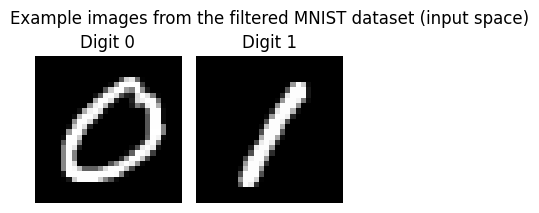

In [10]:
filtered_labels_01 = [0, 1]
train_loader_01 = get_filtered_mnist_train_loader(filtered_labels_01)
plot_input_space(train_loader_01, filtered_labels_01)

Original size of the dataset:  60000
Filtered labels:  [0, 1, 6]
New size of the dataset:  18583


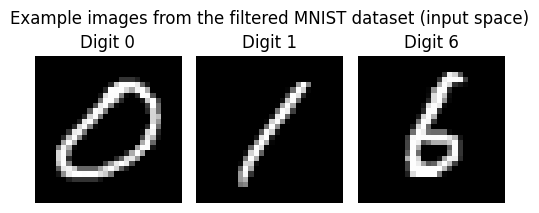

In [11]:
filtered_labels_016 = [0, 1, 6]
train_loader_016 = get_filtered_mnist_train_loader(filtered_labels_016)
plot_input_space(train_loader_016, filtered_labels_016)

# Train VAE

## VAE architecture

In [12]:
class VAE_model(nn.Module):

    def __init__(self, d, D, H, activFun):
        super(VAE_model, self).__init__()

        # Backbone for encoder
        self.enc = nn.Sequential(
            nn.Linear(D, H),
            activFun,
            nn.Linear(H, H),
            activFun
        )
        # Two heads to predict mean and log variance of latent distribution
        self.mu_enc_head    = nn.Linear(H, d)
        self.log_var_enc_head = nn.Linear(H, d)

        # Backbone for decoder
        self.dec = nn.Sequential(
            nn.Linear(d, H),
            activFun,
            nn.Linear(H, H),
            activFun
        )
        self.mu_dec_head      = nn.Linear(H, D)
        self.log_var_dec_head = nn.Linear(H, D)

    def encode(self, x):
        h = self.enc(x)
        return self.mu_enc_head(h), self.log_var_enc_head(h)

    def decode(self, z):
        h = self.dec(z)
        return self.mu_dec_head(h), self.log_var_dec_head(h)

    @staticmethod
    def reparametrization_trick(mu, log_var):
        epsilon = torch.randn_like(mu)
        return mu + torch.exp(0.5 * log_var) * epsilon

    def forward(self, x):
        mu_z, log_var_z = self.encode(x)
        z_rep = self.reparametrization_trick(mu_z, log_var_z)
        mu_x, log_var_x = self.decode(z_rep)
        log_var_x = torch.clamp(log_var_x, -6, 6)
        return mu_x, log_var_x, z_rep, mu_z, log_var_z


def VAE_loss(x, mu_x, log_var_x, mu_z, log_var_z, r=1.0):
    recon_loss = 0.5 * (
        log_var_x + ((x - mu_x)**2 / log_var_x.exp()) + np.log(2 * np.pi)
    ).sum(dim=1).mean()

    kl_loss = 0.5 * (
        mu_z**2 + log_var_z.exp() - log_var_z - 1
    ).sum(dim=1).mean()

    return recon_loss + r * kl_loss, recon_loss.item(), kl_loss.item()

## Training

In [17]:
# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Construct an artificial dataset
D = 28 * 28  # Dimensionality of the input

# Parameters of the VAE
d = 2  # The latent space dimension
activFun = nn.LeakyReLU(0.2)
H = 128
lambda_reg = 1e-7  # For the weights of the networks
epochs = 500
learning_rate = 1e-4
clipping_value = 1
batch_size = 128
r_max = 1  # au lieu de 1.0
warmup = int(0.5 * epochs)

In [9]:
def train_vae(train_loader, epochs, r_max, warmup, clipping_value):
    model = VAE_model(d, D, H, activFun).to(device)
    optimizer_model = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=lambda_reg)

    X_train_list = []

    for X, _ in train_loader:
        X_train_list.append(X)

    X_train = torch.cat(X_train_list).cpu()

    # Train the VAE with the new prior
    ELBO = np.zeros((epochs, 1))

    # Scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_model,
        mode='min',
        factor=0.5,
        patience=20,
        verbose=True
    )

    for epoch in range(epochs):

        model.train()

        train_loss = 0
        train_loss_num = 0

        # Warmup annealing (epoch-level)
        r = min(r_max, epoch / warmup * r_max)

        for X_batch, _ in train_loader:

            X_batch = X_batch.to(device)

            mu_x, log_var_x, z_rep, mu_z, log_var_z = model(X_batch)

            loss, recon, kl = VAE_loss(
                x=X_batch,
                mu_x=mu_x,
                log_var_x=log_var_x,
                mu_z=mu_z,
                log_var_z=log_var_z,
                r=r
            )

            optimizer_model.zero_grad()
            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                clipping_value
            )

            optimizer_model.step()

            train_loss += loss.item()
            train_loss_num += 1

        epoch_loss = train_loss / max(train_loss_num, 1)
        ELBO[epoch] = epoch_loss

        scheduler.step(epoch_loss)

        if epoch % 10 == 0:
            print(f"[Epoch {epoch}/{epochs}] total: {epoch_loss:.1f} | recon: {recon:.1f} | kl: {kl:.3f} | r: {r:.2f}")

    print("Training finished")

    # Plot the ELBO curve
    plt.figure(figsize=(5, 5))
    plt.plot(ELBO, label='ELBO')
    plt.xlabel('Epoch')
    plt.ylabel('ELBO')
    plt.title('ELBO Curve During Training')
    plt.legend()
    plt.grid()
    plt.show()

    return model

[Epoch 0/500] total: 745.0 | recon: 710.9 | kl: 0.347 | r: 0.00
[Epoch 10/500] total: -693.0 | recon: -740.6 | kl: 121.549 | r: 0.04
[Epoch 20/500] total: -767.5 | recon: -798.6 | kl: 187.073 | r: 0.08
[Epoch 30/500] total: -807.9 | recon: -836.7 | kl: 167.300 | r: 0.12
[Epoch 40/500] total: -881.1 | recon: -871.0 | kl: 82.944 | r: 0.16
[Epoch 50/500] total: -922.1 | recon: -910.9 | kl: 56.984 | r: 0.20
[Epoch 60/500] total: -946.3 | recon: -959.5 | kl: 46.427 | r: 0.24
[Epoch 70/500] total: -960.9 | recon: -964.9 | kl: 38.945 | r: 0.28
[Epoch 80/500] total: -970.5 | recon: -985.2 | kl: 31.360 | r: 0.32
[Epoch 90/500] total: -977.8 | recon: -979.7 | kl: 26.343 | r: 0.36
[Epoch 100/500] total: -984.8 | recon: -1015.7 | kl: 24.596 | r: 0.40
[Epoch 110/500] total: -990.3 | recon: -1003.3 | kl: 21.048 | r: 0.44
[Epoch 120/500] total: -995.1 | recon: -1013.1 | kl: 17.897 | r: 0.48
[Epoch 130/500] total: -999.0 | recon: -1008.0 | kl: 16.483 | r: 0.52
[Epoch 140/500] total: -1003.5 | recon: -

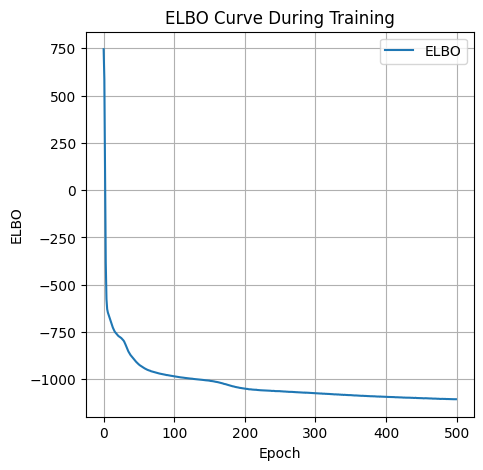

In [11]:
model_01 = train_vae(train_loader_01, epochs, r_max, warmup, clipping_value)

save_path = "saved_model"
if not os.path.exists(save_path):
    os.makedirs(save_path)

torch.save(model_01.state_dict(), os.path.join(save_path, "vae_model_01.pth"))

[Epoch 0/500] total: 721.9 | recon: 619.7 | kl: 4.609 | r: 0.00
[Epoch 10/500] total: -661.3 | recon: -691.3 | kl: 180.311 | r: 0.04
[Epoch 20/500] total: -719.5 | recon: -746.2 | kl: 175.194 | r: 0.08
[Epoch 30/500] total: -794.1 | recon: -810.5 | kl: 95.701 | r: 0.12
[Epoch 40/500] total: -847.1 | recon: -879.2 | kl: 67.266 | r: 0.16
[Epoch 50/500] total: -870.3 | recon: -863.6 | kl: 46.622 | r: 0.20
[Epoch 60/500] total: -885.0 | recon: -900.3 | kl: 40.436 | r: 0.24
[Epoch 70/500] total: -897.6 | recon: -956.5 | kl: 36.687 | r: 0.28
[Epoch 80/500] total: -906.6 | recon: -902.9 | kl: 24.868 | r: 0.32
[Epoch 90/500] total: -914.0 | recon: -941.7 | kl: 22.751 | r: 0.36
[Epoch 100/500] total: -926.0 | recon: -944.4 | kl: 20.289 | r: 0.40
[Epoch 110/500] total: -933.7 | recon: -942.8 | kl: 17.147 | r: 0.44
[Epoch 120/500] total: -939.7 | recon: -959.4 | kl: 17.674 | r: 0.48
[Epoch 130/500] total: -945.2 | recon: -990.1 | kl: 16.309 | r: 0.52
[Epoch 140/500] total: -950.6 | recon: -974.0 

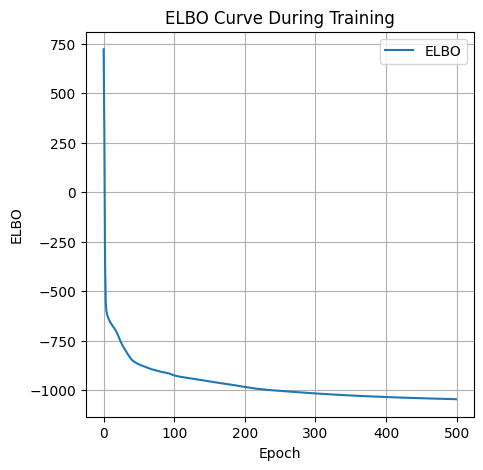

In [12]:
model_016 = train_vae(train_loader_016, epochs, r_max, warmup, clipping_value)

save_path = "saved_model"
if not os.path.exists(save_path):
    os.makedirs(save_path)

torch.save(model_016.state_dict(), os.path.join(save_path, "vae_model_016.pth"))

## Sanity checks

In [39]:
model_01 = VAE_model(d, D, H, activFun).to(device)

# if models already exist, load them
model_path = "saved_models/vae_model_01.pt"
if os.path.exists(model_path):
    model_01.load_state_dict(torch.load(model_path))
    print(f"Model loaded from {model_path}")

model_016 = VAE_model(d, D, H, activFun).to(device)

model_path = "saved_models/vae_model_016.pt"
if os.path.exists(model_path):
    model_016.load_state_dict(torch.load(model_path))
    print(f"Model loaded from {model_path}")

Model loaded from saved_models/vae_model_01.pt
Model loaded from saved_models/vae_model_016.pt


In [40]:
# Extract the latent representations for the training data
Z_01, labels_01, X_train_01 = extract_representation(model_01, train_loader_01, device)

Z_016, labels_016, X_train_016 = extract_representation(model_016, train_loader_016, device)

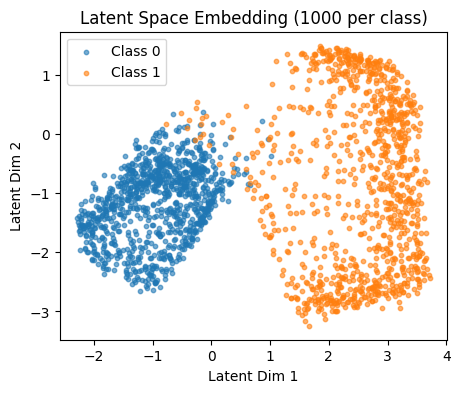

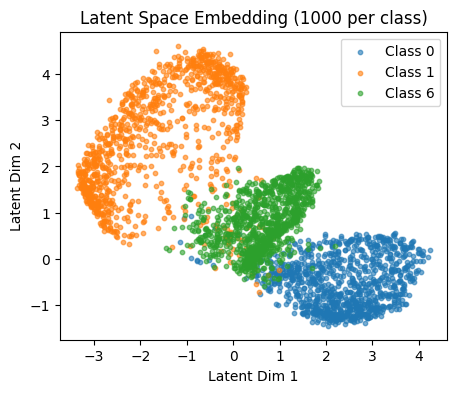

In [41]:
plot_latent_space(Z_01, labels_01)
plot_latent_space(Z_016, labels_016)

# Clustering

## Riemannian distance

In [42]:
def precompute_M(model, device, grid_size=50, z_range=(-3, 3)):
    xs = torch.linspace(z_range[0], z_range[1], grid_size, device=device)
    ys = torch.linspace(z_range[0], z_range[1], grid_size, device=device)
    
    grid_z = torch.stack(torch.meshgrid(xs, ys, indexing='ij'), dim=-1).reshape(-1, 2)
    
    all_M = []
    
    # batch=1 to compute Jacobian for each point separately
    for i in range(len(grid_z)):
        z_single = grid_z[i:i+1].clone().detach().requires_grad_(True)
        J = torch.autograd.functional.jacobian(
            lambda z: model.decode(z)[0], z_single, vectorize=True
        )  # (1, D, 1, d)
        J = J[0, :, 0, :]  # (D, d)
        M = J.T @ J  # (d, d)
        all_M.append(M.detach())
    
    all_M = torch.stack(all_M, dim=0)  # (grid_size², d, d)
    return grid_z.detach(), all_M


def lookup_metric_batch(z_points, grid_z, all_M, grid_size=50):
    # Normalise z_points to [0, grid_size-1]
    z_min = grid_z.min(dim=0).values
    z_max = grid_z.max(dim=0).values
    
    z_norm = (z_points - z_min) / (z_max - z_min) * (grid_size - 1)
    
    x0 = z_norm[:, 0].long().clamp(0, grid_size - 2)
    y0 = z_norm[:, 1].long().clamp(0, grid_size - 2)
    x1 = x0 + 1
    y1 = y0 + 1

    # Bilinear interpolation weights
    wx = (z_norm[:, 0] - x0.float()).unsqueeze(1).unsqueeze(2)
    wy = (z_norm[:, 1] - y0.float()).unsqueeze(1).unsqueeze(2)

    all_M_grid = all_M.reshape(grid_size, grid_size, 2, 2)

    M00 = all_M_grid[x0, y0]
    M01 = all_M_grid[x0, y1]
    M10 = all_M_grid[x1, y0]
    M11 = all_M_grid[x1, y1]

    M = (1 - wx) * (1 - wy) * M00 + \
        (1 - wx) * wy       * M01 + \
        wx       * (1 - wy) * M10 + \
        wx       * wy       * M11

    return M


def riemannian_distance_batch(Z, centers, grid_z, all_M, steps=20, grid_size=50):
    N, d = Z.shape
    K = centers.shape[0]
    device = Z.device
    dists = torch.zeros(N, K, device=device)
    path = torch.linspace(0, 1, steps, device=device)

    for k in range(K):
        z_path = Z.unsqueeze(0) + path.view(-1,1,1) * (centers[k] - Z).unsqueeze(0)
        dist = torch.zeros(N, device=device)

        for t in range(steps - 1):
            z_mid = (z_path[t] + z_path[t+1]) / 2  # (N, d)
            dz = z_path[t+1] - z_path[t]            # (N, d)

            M = lookup_metric_batch(z_mid, grid_z, all_M, grid_size)  # (N, d, d)

            # dz^T G dz vectorized for all points in the batch
            scalar = torch.bmm(
                dz.unsqueeze(1),               # (N, 1, d)
                torch.bmm(M, dz.unsqueeze(2))  # (N, d, 1)
            ).squeeze()                         # (N,)

            dist += torch.sqrt(torch.clamp(scalar, min=1e-10))

        dists[:, k] = dist

    return dists


## Kmeans

In [43]:
def kmeans_euclidean(Z, true_labels, n_clusters=3):
    kmeans = KMeans(n_clusters=n_clusters, n_init=30)
    pred_labels = kmeans.fit_predict(Z) # uses Euclidean distance by default

    pred_labels = match_labels(true_labels, pred_labels)
    
    f1 = f1_score(true_labels, pred_labels, average="macro")
    return f1, pred_labels


def kmeans_riemannian(Z, labels, model, n_clusters=3, n_iter=20):
    Z_cpu = Z.detach().cpu().numpy()
    labels_np = labels.cpu().numpy() if isinstance(labels, torch.Tensor) else labels

    kmeans = KMeans(n_clusters=n_clusters, n_init=10)
    kmeans.fit(Z_cpu)

    Z_tensor = Z.to(next(model.parameters()).device)
    centers = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32, device=Z_tensor.device)

    grid_size=100
    # Precompute the M once for all iterations
    print("Precomputing M...")
    grid_z, all_M = precompute_M(model, Z_tensor.device, grid_size=grid_size)
    print("Done.")

    for it in range(n_iter):
        dists = riemannian_distance_batch(Z_tensor, centers, grid_z, all_M, grid_size=grid_size) # Approximate Riemannian distance
        assignments = dists.argmin(dim=1).cpu().numpy()

        for k in range(n_clusters):
            idx = assignments == k
            if idx.sum() > 0:
                centers[k] = Z_tensor[idx].mean(dim=0)

    assignments = match_labels(labels_np, assignments)
    f1 = f1_score(labels_np, assignments, average="macro")
    return f1, assignments

def match_labels(true_labels, pred_labels):
    unique = np.unique(true_labels)
    cm = confusion_matrix(true_labels, pred_labels, labels=unique)
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {col: unique[row] for row, col in zip(row_ind, col_ind)}
    return np.array([mapping[p] for p in pred_labels])


## Results

In [45]:
# Euclidean clustering
Z_sub, labels_sub = sample_per_class(Z_016, labels_016, 1000)

f1_euclid, pred_eucl = kmeans_euclidean(Z_sub.numpy(), labels_sub.numpy())
f1_riem, pred_riem = kmeans_riemannian(Z_sub.to(device), labels_sub.to(device), model_016)

print("Euclidean F1:", f1_euclid)
print("Riemannian F1:", f1_riem)

Precomputing M...
Done.
Euclidean F1: 0.9304628025274938
Riemannian F1: 0.9353438508399461


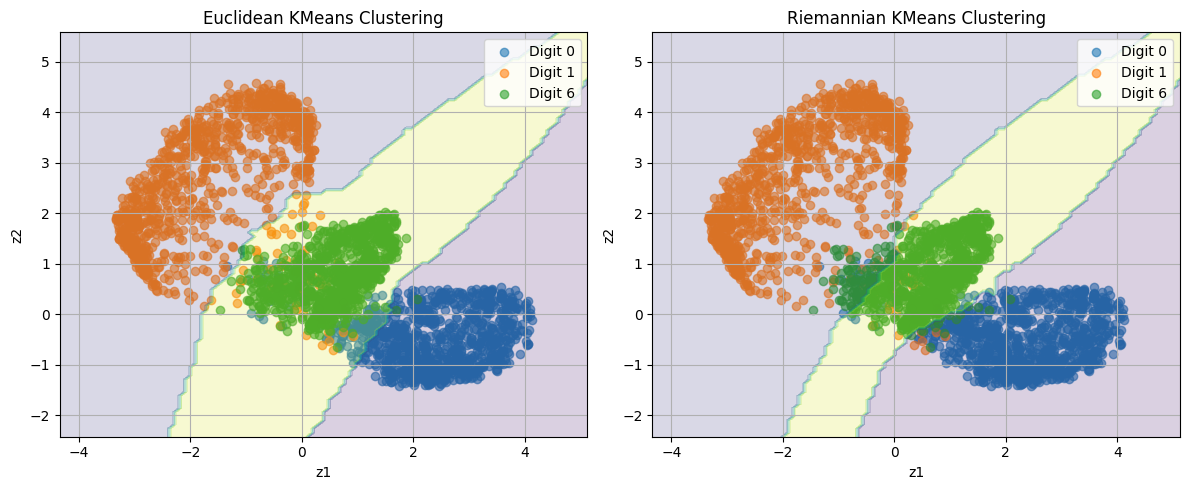

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_clustering_boundary(
    Z_sub.cpu().numpy(),
    labels_sub.cpu().numpy(),
    pred_eucl,
    axes[0],
    "Euclidean KMeans Clustering"
)

plot_clustering_boundary(
    Z_sub.cpu().numpy(),
    labels_sub.cpu().numpy(),
    pred_riem,
    axes[1],
    "Riemannian KMeans Clustering"
)

plt.tight_layout()
plt.show()

# Geodesic vs Linear Interpolation

## RBF Architecture

In [47]:
class RBF_Variance(nn.Module):
    """
    Models the precision (inverse variance) of the decoder with an RBF network.
    beta(z) = W * v(z) + zeta
    where v_k(z) = exp(-lambda_k * ||z - c_k||²)
    """

    def __init__(self, d, D, K, zeta=1e-6):
        super(RBF_Variance, self).__init__()

        self.d = d  # latent dimension
        self.D = D  # input dimension
        self.K = K  # number of RBF centers
        self.zeta = zeta  # small constant to avoid division by zero

        # Centers and bandwidths (not trained, fixed by KMeans)
        self.register_buffer('centers', torch.zeros(K, d))
        self.register_buffer('lambdas', torch.ones(K))

        # Weights W > 0 (positivity constraint via softplus)
        self.W_raw = nn.Parameter(torch.randn(D, K))

    @property
    def W(self):
        return torch.nn.functional.softplus(self.W_raw)  # force W > 0

    def init_centers(self, Z, a=1.0):
        """
        Initializes centers with KMeans and bandwidths according to eq. 11
        Z : (N, d) tensor of encoded latent points
        a : curvature hyperparameter
        """
        Z_np = Z.detach().cpu().numpy()

        kmeans = KMeans(n_clusters=self.K, n_init=10)
        kmeans.fit(Z_np)

        centers = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32)
        self.centers.copy_(centers)

        # Compute bandwidths according to eq. 11 of the paper
        # lambda_k = 0.5 * (a * (1/|C_k|) * sum ||z_j - c_k||²)^(-2)
        labels = kmeans.labels_
        lambdas = []

        for k in range(self.K):
            idx = labels == k
            if idx.sum() > 0:
                z_k = torch.tensor(Z_np[idx], dtype=torch.float32)
                c_k = centers[k]
                mean_dist = ((z_k - c_k) ** 2).sum(dim=1).mean().item()
                lam = 0.5 * (a * mean_dist) ** (-2)
            else:
                lam = 1.0
            lambdas.append(lam)

        self.lambdas.copy_(torch.tensor(lambdas, dtype=torch.float32))
        print(f"RBF centers initialized")

    def forward(self, z):
        """
        z : (N, d)
        returns log_var : (N, D) — log variance of the decoder
        """
        # v_k(z) = exp(-lambda_k * ||z - c_k||²)
        diff = z.unsqueeze(1) - self.centers.unsqueeze(0)  # (N, K, d)
        sq_dist = (diff ** 2).sum(dim=2)                   # (N, K)
        v = torch.exp(-self.lambdas * sq_dist)             # (N, K)

        # beta(z) = W * v(z) + zeta — precision
        beta = v @ self.W.T + self.zeta                    # (N, D)

        # variance = 1 / beta, log_var = -log(beta)
        log_var = -torch.log(beta)

        return log_var

## RBF Training

RBF centers initialized
[RBF Epoch 0/5000] loss: 901.842
[RBF Epoch 100/5000] loss: 666.638
[RBF Epoch 200/5000] loss: 499.817
[RBF Epoch 300/5000] loss: 381.669
[RBF Epoch 400/5000] loss: 294.942
[RBF Epoch 500/5000] loss: 228.174
[RBF Epoch 600/5000] loss: 174.444
[RBF Epoch 700/5000] loss: 129.629
[RBF Epoch 800/5000] loss: 91.196
[RBF Epoch 900/5000] loss: 57.521
[RBF Epoch 1000/5000] loss: 27.514
[RBF Epoch 1100/5000] loss: 0.413
[RBF Epoch 1200/5000] loss: -24.333
[RBF Epoch 1300/5000] loss: -47.132
[RBF Epoch 1400/5000] loss: -68.295
[RBF Epoch 1500/5000] loss: -88.067
[RBF Epoch 1600/5000] loss: -106.640
[RBF Epoch 1700/5000] loss: -124.169
[RBF Epoch 1800/5000] loss: -140.782
[RBF Epoch 1900/5000] loss: -156.583
[RBF Epoch 2000/5000] loss: -171.662
[RBF Epoch 2100/5000] loss: -186.092
[RBF Epoch 2200/5000] loss: -199.936
[RBF Epoch 2300/5000] loss: -213.251
[RBF Epoch 2400/5000] loss: -226.082
[RBF Epoch 2500/5000] loss: -238.471
[RBF Epoch 2600/5000] loss: -250.453
[RBF Epoch

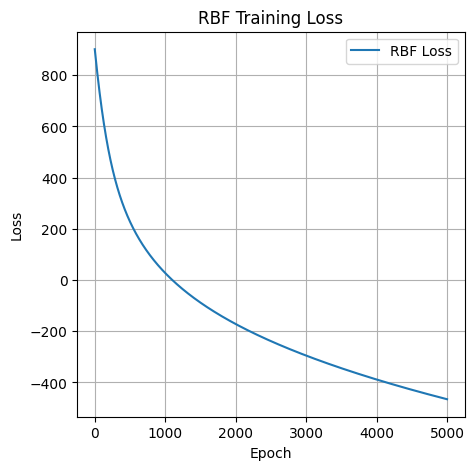

In [ ]:
# Create and initialize the RBF layer
K = 15  # Number of RBF centers
rbf = RBF_Variance(d=d, D=D, K=K, zeta=1e-6).to(device)
rbf.init_centers(Z_01, a=1.25)

# Train the RBF layer
optimizer_rbf = torch.optim.Adam(rbf.parameters(), lr=1e-2)

rbf.train()
model_01.eval()

Z_train = Z_01.to(device)
X_train = X_train_01.to(device)

losses = []
epochs=5000

for epoch in range(epochs):
    # Fixed reconstruction mean from VAE
    with torch.no_grad():
        mu_x = model_01.decode(Z_train)[0]  # (N, D)

    # RBF variance
    log_var = rbf(Z_train)              # (N, D)
    log_var = torch.clamp(log_var, -10, 10)

    # Gaussian log-likelihood
    recon_loss = 0.5 * (
        log_var + ((X_train - mu_x) ** 2) / log_var.exp()
    ).sum(dim=1).mean()

    optimizer_rbf.zero_grad()
    recon_loss.backward()
    optimizer_rbf.step()

    losses.append(recon_loss.item())

    if epoch % 100 == 0:
        print(f"[RBF Epoch {epoch}/{epochs}] loss: {recon_loss.item():.3f}")

# Plot RBF training loss
plt.figure(figsize=(5, 5))
plt.plot(losses, label='RBF Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('RBF Training Loss')
plt.legend()
plt.grid()
plt.show()

In [ ]:
torch.save(rbf.state_dict(), 'saved_model/rbf_variance_01.pt')

## Results

In [48]:
# If model already exists, load it

K = 15  # Number of RBF centers
rbf = RBF_Variance(d=d, D=D, K=K, zeta=1e-6).to(device)
rbf.init_centers(Z_01, a=1.25)

rbf.load_state_dict(torch.load('saved_model/rbf_variance_01.pt'))

RBF centers initialized


<All keys matched successfully>

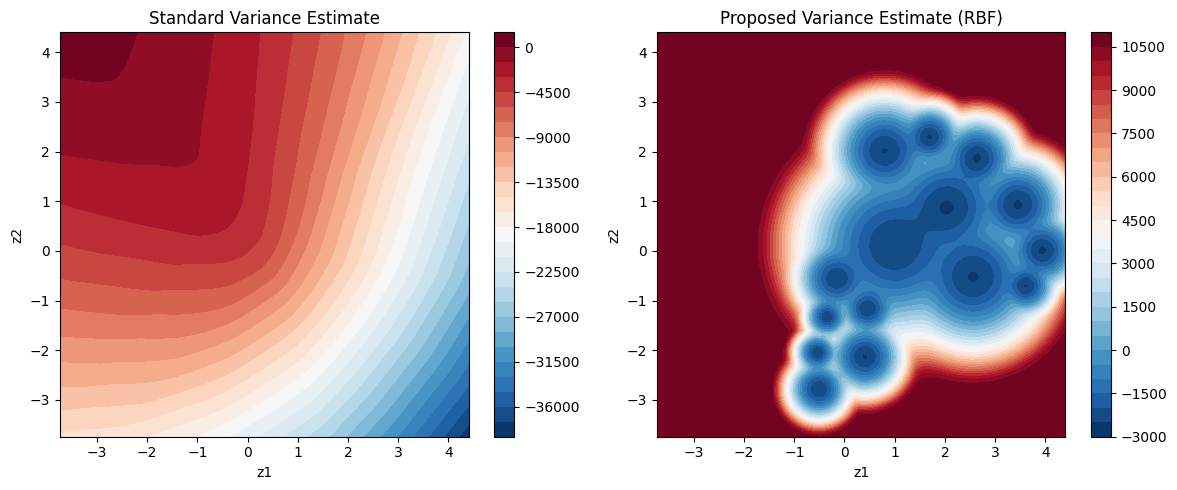

In [49]:
plot_variance_comparison(model_01, rbf, Z_01.cpu().numpy(), device)

In [50]:
def plot_geodesic(model, rbf_model, Z_np, labels_np, z_start, z_end, device, grid_size=100, geodesic_steps=30):

    z_range = (Z_np.min() - 0.5, Z_np.max() + 0.5)

    # Precompute riemannian metric on a grid
    grid_z, all_M = precompute_M(model, device, grid_size=grid_size, z_range=z_range)
    all_M = all_M.to(device)

    xx, yy = np.meshgrid(
        np.linspace(z_range[0], z_range[1], grid_size),
        np.linspace(z_range[0], z_range[1], grid_size)
    )

    # Heatmap variance RBF
    rbf_model.eval()
    xs = torch.linspace(z_range[0], z_range[1], grid_size, device=device)
    ys = torch.linspace(z_range[0], z_range[1], grid_size, device=device)
    grid_z_plot = torch.stack(torch.meshgrid(xs, ys, indexing='ij'), dim=-1).reshape(-1, 2)
    with torch.no_grad():
        log_var_rbf = rbf_model(grid_z_plot)
        variance_rbf = log_var_rbf.mean(dim=1).cpu().numpy().reshape(grid_size, grid_size)

    # Fix start and end points
    z1 = torch.tensor(z_start, dtype=torch.float32, device=device)
    z2 = torch.tensor(z_end, dtype=torch.float32, device=device)

    # Linear initialization of the path
    t = torch.linspace(0, 1, geodesic_steps, device=device)
    path_init = z1 + t.unsqueeze(1) * (z2 - z1)
    path_inner = path_init[1:-1].clone().detach().requires_grad_(True)
    optimizer_geo = torch.optim.Adam([path_inner], lr=5e-3)

    for _ in range(2000):
        full_path = torch.cat([z1.unsqueeze(0), path_inner, z2.unsqueeze(0)], dim=0)

        energy = torch.tensor(0.0, device=device)
        for i in range(len(full_path) - 1):
            dz = full_path[i+1] - full_path[i]          # (2,)
            z_mid = (full_path[i] + full_path[i+1]) / 2  # (2,)

            # Lookup metric at the midpoint using precomputed grid
            M = lookup_metric_batch(
                z_mid.unsqueeze(0), grid_z, all_M, grid_size
            )[0]  # (2, 2)

            energy = energy + torch.sqrt(
                torch.clamp(dz @ M @ dz, min=1e-10)
            )

        optimizer_geo.zero_grad()
        energy.backward()
        optimizer_geo.step()

    with torch.no_grad():
        geodesic_path = torch.cat([
            z1.unsqueeze(0), path_inner, z2.unsqueeze(0)
        ], dim=0).cpu().numpy()

    linear_path = np.array([
        z_start + t_val * (z_end - z_start)
        for t_val in np.linspace(0, 1, geodesic_steps)
    ])

    # Plot
    plt.figure(figsize=(5, 5))
    plt.contourf(xx, yy, variance_rbf.T, levels=30, cmap="RdBu_r")
    plt.colorbar()

    colors = ['green', 'orange']
    for i, cls in enumerate(np.unique(labels_np)):
        idx = labels_np == cls
        plt.scatter(Z_np[idx, 0], Z_np[idx, 1], alpha=0.3, s=5, color=colors[i], label=f"Class {cls}")

    plt.plot(geodesic_path[:, 0], geodesic_path[:, 1], 'r-', linewidth=2.5, label="Geodesic curve")
    plt.plot(linear_path[:, 0], linear_path[:, 1], 'k--', linewidth=2.5, label="Linear interpolation")

    plt.legend(fontsize=12)
    plt.xlabel("z1")
    plt.ylabel("z2")
    plt.title("Geodesic vs Linear Interpolation")
    plt.show()

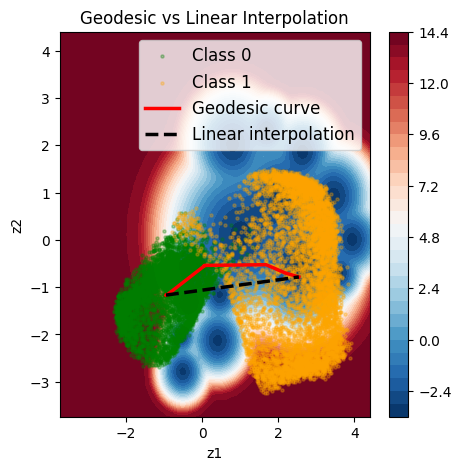

In [51]:
Z_np = Z_01.cpu().numpy()
labels_np = labels_01.cpu().numpy()

# Taking the clusters centers as the mean of the latent representations for each class
z_start = Z_np[labels_np == 0].mean(axis=0)  # center classe 0
z_end   = Z_np[labels_np == 1].mean(axis=0)  # center classe 1

plot_geodesic(model_01, rbf, Z_np, labels_np, z_start, z_end, device)

# Interpolation

In [52]:
def interpolate_latent(model, rbf_model, z_start, z_end, device, steps=10, geodesic_optim_steps=2000):
    """
    Interpolates between two latent points and decodes to image space.
    Returns linear and geodesic interpolations.
    """
    z1 = torch.tensor(z_start, dtype=torch.float32, device=device)
    z2 = torch.tensor(z_end, dtype=torch.float32, device=device)

    # Linear interpolation
    t = torch.linspace(0, 1, steps, device=device)
    linear_path = z1 + t.unsqueeze(1) * (z2 - z1)  # (steps, 2)

    # Geodesic interpolation
    path_init = linear_path.clone()
    path_inner = path_init[1:-1].clone().detach().requires_grad_(True)
    optimizer_geo = torch.optim.Adam([path_inner], lr=5e-3)

    rbf_model.eval()
    for _ in range(geodesic_optim_steps):
        full_path = torch.cat([z1.unsqueeze(0), path_inner, z2.unsqueeze(0)], dim=0)

        energy = torch.tensor(0.0, device=device)
        for i in range(len(full_path) - 1):
            dz = full_path[i+1] - full_path[i]
            z_mid = (full_path[i] + full_path[i+1]) / 2

            log_v = rbf_model(z_mid.unsqueeze(0))   # (1, D)
            weight = log_v.exp().mean()              # différentiable

            energy = energy + weight * (dz ** 2).sum()

        optimizer_geo.zero_grad()
        energy.backward()
        optimizer_geo.step()

    with torch.no_grad():
        geodesic_path = torch.cat([
            z1.unsqueeze(0), path_inner, z2.unsqueeze(0)
        ], dim=0)  # (steps, 2)

    # Decode both paths
    model.eval()
    with torch.no_grad():
        linear_imgs = model.decode(linear_path)[0]      # (steps, D)
        geodesic_imgs = model.decode(geodesic_path)[0]  # (steps, D)

    return linear_imgs.cpu(), geodesic_imgs.cpu()


def plot_interpolation(model, rbf_model, Z_np, labels_np, device, steps=8):
    """
    Pick one point from each class and interpolate.
    """
    # Take one representative point from each class (closest to the class center)
    for cls in np.unique(labels_np):
        idx = np.where(labels_np == cls)[0]
        center = Z_np[idx].mean(axis=0)
        dists = ((Z_np[idx] - center) ** 2).sum(axis=1)
        representative = Z_np[idx[dists.argmin()]]
        if cls == np.unique(labels_np)[0]:
            z_start = representative
        else:
            z_end = representative

    linear_imgs, geodesic_imgs = interpolate_latent(
        model, rbf_model, z_start, z_end, device, steps=steps
    )

    # Plot
    img_size = int(linear_imgs.shape[1] ** 0.5)  # 28 for MNIST

    fig, axes = plt.subplots(2, steps, figsize=(steps * 2, 4))

    for i in range(steps):
        # Linear
        axes[0, i].imshow(
            linear_imgs[i].reshape(img_size, img_size).numpy(),
            cmap='gray', vmin=0, vmax=1
        )
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title('Linear', fontsize=10, loc='left')

        # Geodesic
        axes[1, i].imshow(
            geodesic_imgs[i].reshape(img_size, img_size).numpy(),
            cmap='gray', vmin=0, vmax=1
        )
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title('Geodesic', fontsize=10, loc='left')

    plt.suptitle("Latent Space Interpolation: Linear vs Geodesic", fontsize=13)
    plt.tight_layout()
    plt.show()

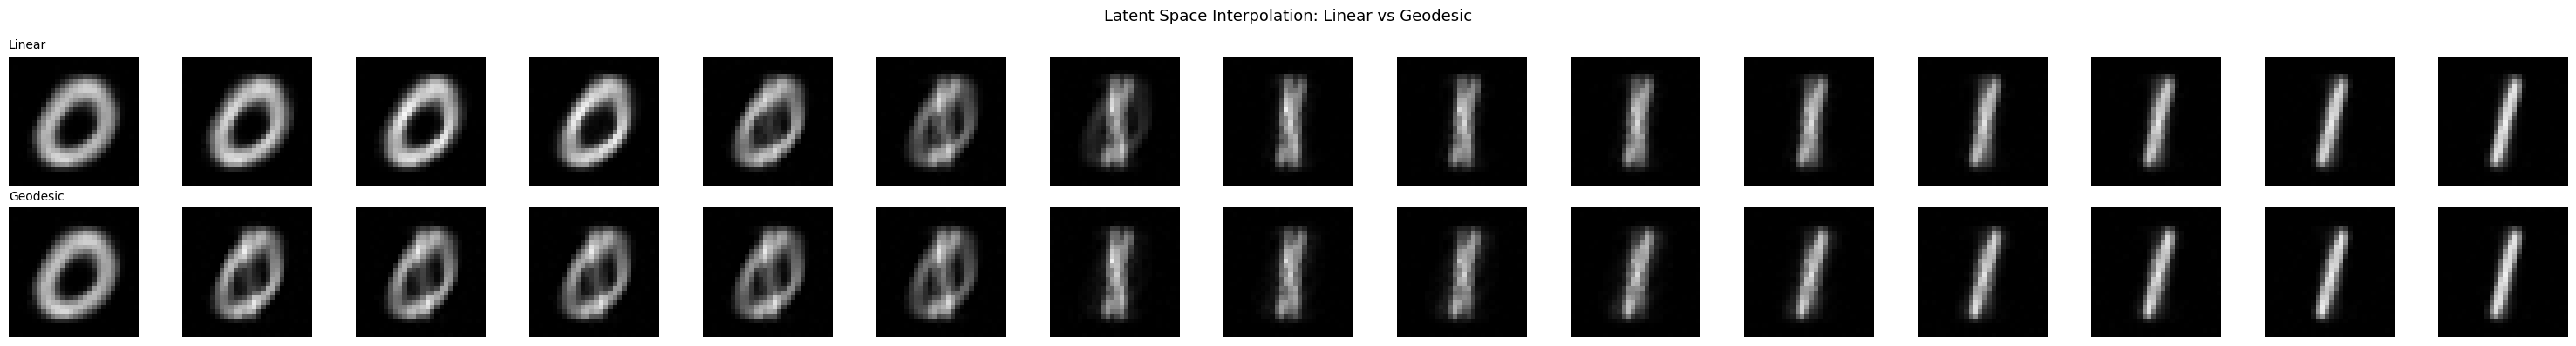

In [53]:
plot_interpolation(model_01, rbf, Z_01.cpu().numpy(), labels_01.cpu().numpy(), device, steps=15)